In [102]:
## 1. Chargement des données
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "1"

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Remplacez par le chemin correct vers votre CSV
data = pd.read_csv('airbnb_train.csv')


In [103]:
# Si on a déjà une colonne log_price, on en déduit price ; sinon l’inverse
if 'log_price' in data.columns:
    data['price']     = np.expm1(data['log_price'])
else:
    data['log_price'] = np.log1p(data['price'])


In [104]:
print(f"Forme du DataFrame : {data.shape}")
print("\nValeurs manquantes par colonne :")
print(data.isnull().sum())


Forme du DataFrame : (22234, 29)

Valeurs manquantes par colonne :
id                           0
log_price                    0
property_type                0
room_type                    0
amenities                    0
accommodates                 0
bathrooms                   51
bed_type                     0
cancellation_policy          0
cleaning_fee                 0
city                         0
description                  0
first_review              4725
host_has_profile_pic        56
host_identity_verified      56
host_response_rate        5475
host_since                  56
instant_bookable             0
last_review               4716
latitude                     0
longitude                    0
name                         0
neighbourhood             2086
number_of_reviews            0
review_scores_rating      4978
zipcode                    303
bedrooms                    26
beds                        35
price                        0
dtype: int64


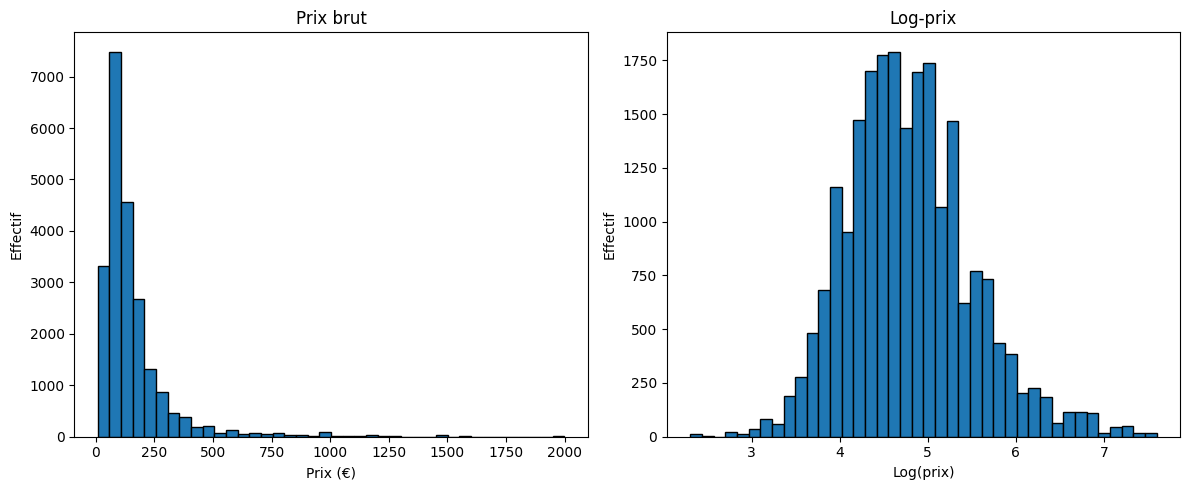

In [105]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(data['price'].dropna(), bins=40, edgecolor='black')
plt.title('Prix brut')
plt.xlabel('Prix (€)')
plt.ylabel('Effectif')

plt.subplot(1,2,2)
plt.hist(data['log_price'].dropna(), bins=40, edgecolor='black')
plt.title('Log-prix')
plt.xlabel('Log(prix)')
plt.ylabel('Effectif')

plt.tight_layout()
plt.show()


In [106]:
# Nettoyage manuel et split
amen_raw = (
    data['amenities']
        .fillna('[]')
        .str.replace(r'[\{\}"]', '', regex=True)
        .str.split(',')
        .apply(lambda lst: [x.strip() for x in lst if x.strip()])
)

# Liste plate de tous les items, sélection du top25
all_items = pd.Series([item for sub in amen_raw for item in sub])
top25      = all_items.value_counts().head(25).index.tolist()

# Encodage binaire
for amen in top25:
    col = f"has_{amen.replace(' ', '_')}"
    data[col] = amen_raw.apply(lambda lst: int(amen in lst))


In [107]:
city_counts = data['city'].value_counts()
rare       = city_counts[city_counts < 75].index
data['city_cat'] = data['city'].where(~data['city'].isin(rare), 'Other')


In [108]:
data['price_per_guest']    = data['price'] / data['accommodates']
data['beds_per_bedroom']   = data['beds']  / (data['bedrooms'] + 1e-6)
data['bath_per_bed_ratio'] = data['bathrooms'] / (data['beds'] + 1e-6)


In [109]:
# 8. Clustering géographique (KMeans avec 5 clusters)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

coords = data[['latitude', 'longitude']].dropna()
coords_norm = StandardScaler().fit_transform(coords)

kmeans = KMeans(n_clusters=5, random_state=42).fit(coords_norm)

# Créez une colonne 'geo_group' avec des NaN
data['geo_group'] = np.nan

# Utilisez `.iloc` pour assigner les labels en fonction de la position
data.loc[coords.index, 'geo_group'] = pd.Series(kmeans.labels_, index=coords.index)



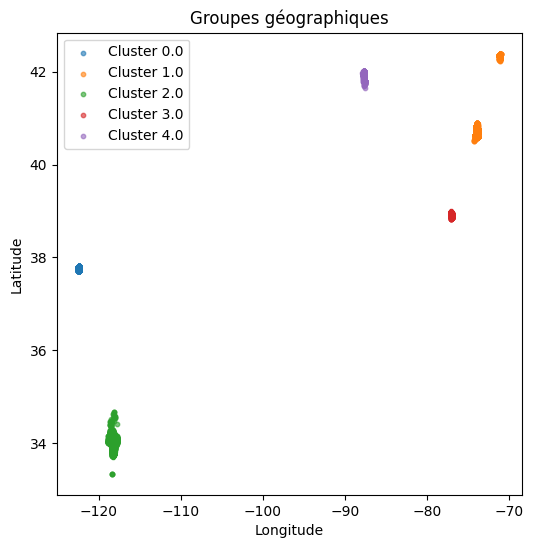

In [110]:
plt.figure(figsize=(6,6))
for grp in sorted(data['geo_group'].unique()):
    sub = data[data['geo_group'] == grp]
    plt.scatter(
        sub['longitude'], sub['latitude'],
        s=10, alpha=0.6, label=f'Cluster {grp}'
    )
plt.legend()
plt.title('Groupes géographiques')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


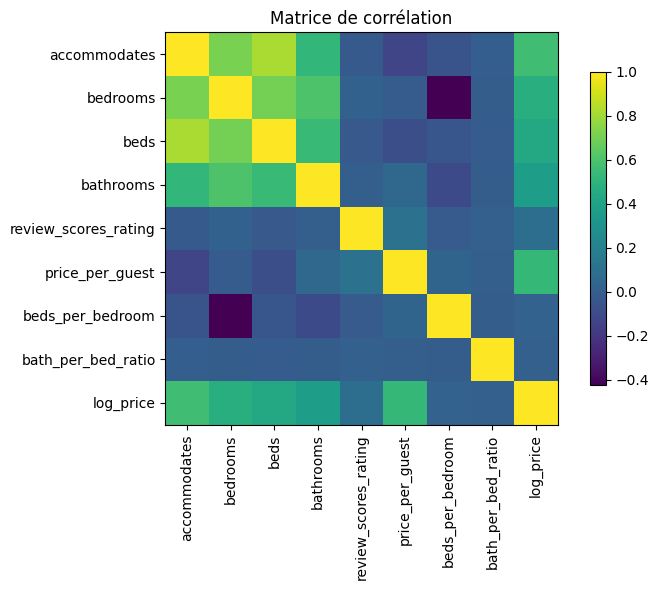

In [111]:
features = [
    'accommodates','bedrooms','beds','bathrooms','review_scores_rating',
    'price_per_guest','beds_per_bedroom','bath_per_bed_ratio','log_price'
]
corr_matrix = data[features].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr_matrix, interpolation='nearest')
plt.colorbar(shrink=0.8)
plt.xticks(range(len(features)), features, rotation=90)
plt.yticks(range(len(features)), features)
plt.title('Matrice de corrélation')
plt.tight_layout()
plt.show()


In [112]:
print("Colonnes utilisées dans le DataFrame final :")
for col in data.columns:
    print("-", col)


Colonnes utilisées dans le DataFrame final :
- id
- log_price
- property_type
- room_type
- amenities
- accommodates
- bathrooms
- bed_type
- cancellation_policy
- cleaning_fee
- city
- description
- first_review
- host_has_profile_pic
- host_identity_verified
- host_response_rate
- host_since
- instant_bookable
- last_review
- latitude
- longitude
- name
- neighbourhood
- number_of_reviews
- review_scores_rating
- zipcode
- bedrooms
- beds
- price
- has_Wireless_Internet
- has_Kitchen
- has_Heating
- has_Essentials
- has_Smoke_detector
- has_Air_conditioning
- has_TV
- has_Shampoo
- has_Hangers
- has_Carbon_monoxide_detector
- has_Internet
- has_Laptop_friendly_workspace
- has_Washer
- has_Hair_dryer
- has_Dryer
- has_Iron
- has_Family/kid_friendly
- has_Fire_extinguisher
- has_First_aid_kit
- has_translation_missing:_en.hosting_amenity_50
- has_Cable_TV
- has_Free_parking_on_premises
- has_translation_missing:_en.hosting_amenity_49
- has_24-hour_check-in
- has_Lock_on_bedroom_door
- 

In [113]:
# 12. Sauvegarde du DataFrame traité
data.to_csv('airbnb_train_processed.csv', index=False)
print("Fichier enregistré avec succès.")


Fichier enregistré avec succès.


In [127]:
import pandas as pd
import numpy as np

from sklearn.model_selection   import train_test_split, GridSearchCV
from sklearn.compose           import ColumnTransformer
from sklearn.preprocessing     import StandardScaler, OneHotEncoder
from sklearn.ensemble          import RandomForestRegressor
from sklearn.pipeline          import Pipeline
from sklearn.metrics           import mean_squared_error, r2_score

In [131]:
df = pd.read_csv('airbnb_train_processed.csv')
df.columns.tolist()

C:\Users\aurel\AppData\Local\Temp\ipykernel_23900\3961353485.py:1: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('airbnb_train_processed.csv')


['id',
 'log_price',
 'property_type',
 'room_type',
 'amenities',
 'accommodates',
 'bathrooms',
 'bed_type',
 'cancellation_policy',
 'cleaning_fee',
 'city',
 'description',
 'first_review',
 'host_has_profile_pic',
 'host_identity_verified',
 'host_response_rate',
 'host_since',
 'instant_bookable',
 'last_review',
 'latitude',
 'longitude',
 'name',
 'neighbourhood',
 'number_of_reviews',
 'review_scores_rating',
 'zipcode',
 'bedrooms',
 'beds',
 'price',
 'has_Wireless_Internet',
 'has_Kitchen',
 'has_Heating',
 'has_Essentials',
 'has_Smoke_detector',
 'has_Air_conditioning',
 'has_TV',
 'has_Shampoo',
 'has_Hangers',
 'has_Carbon_monoxide_detector',
 'has_Internet',
 'has_Laptop_friendly_workspace',
 'has_Washer',
 'has_Hair_dryer',
 'has_Dryer',
 'has_Iron',
 'has_Family/kid_friendly',
 'has_Fire_extinguisher',
 'has_First_aid_kit',
 'has_translation_missing:_en.hosting_amenity_50',
 'has_Cable_TV',
 'has_Free_parking_on_premises',
 'has_translation_missing:_en.hosting_amenit

In [129]:
# Remplacez par le chemin de votre CSV post-traité
df = pd.read_csv('airbnb_train_processed.csv')

# Cible
y = df['log_price']

# Caractéristiques numériques
num_feats = [
    'accommodates', 'bedrooms', 'beds', 'bathrooms',
    'review_scores_rating', 'price_per_guest',      
    'beds_per_bedroom', 'bath_per_bed_ratio',        
    'latitude', 'longitude'
]


# Catégorielles
cat_feats = ['city_cat', 'room_type', 'property_type', 'geo_group']

# Amenities (toutes les colonnes commençant par 'has_')
amen_feats = [c for c in df.columns if c.startswith('has_')]

X = df[num_feats + cat_feats + amen_feats]


C:\Users\aurel\AppData\Local\Temp\ipykernel_23900\2249450305.py:2: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('airbnb_train_processed.csv')


In [132]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [133]:
# Prétraitements
preprocessor = ColumnTransformer([
    ('scale', StandardScaler(), num_feats),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_feats)
], remainder='passthrough')  # amenities passent tels quels

# Pipeline complet
pipeline = Pipeline([
    ('prep', preprocessor),
    ('rf', RandomForestRegressor(random_state=0))
])


In [134]:
param_grid = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth'   : [10, 20, None]
}

grid = GridSearchCV(
    pipeline, param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=1,
    verbose=1
)

grid.fit(X_train, y_train)
print("Meilleurs paramètres :", grid.best_params_)
print("RMSE CV (grid)      :", -grid.best_score_)


Fitting 3 folds for each of 6 candidates, totalling 18 fits
Meilleurs paramètres : {'rf__max_depth': None, 'rf__n_estimators': 200}
RMSE CV (grid)      : 0.036253183538106575


In [135]:
best_model = grid.best_estimator_
y_pred     = best_model.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
r2_test   = r2_score(y_test, y_pred)

print(f"RMSE test : {rmse_test:.3f}")
print(f"R² test   : {r2_test:.3f}")


RMSE test : 0.034
R² test   : 0.998


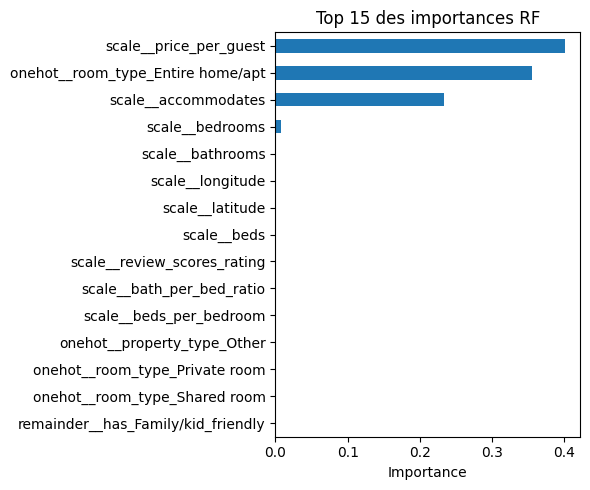

In [136]:
# Récupérer noms de features après transformation
feat_names = best_model.named_steps['prep'].get_feature_names_out()

# Extraire importances du RandomForest
importances = best_model.named_steps['rf'].feature_importances_

# Construire une Series et afficher top 15
import pandas as pd
imp_series = pd.Series(importances, index=feat_names)
top15      = imp_series.sort_values(ascending=False).head(15)

import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
top15.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 15 des importances RF")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


In [137]:
print("Total features utilisées :", len(feat_names))
for f in feat_names:
    print("-", f)


Total features utilisées : 78
- scale__accommodates
- scale__bedrooms
- scale__beds
- scale__bathrooms
- scale__review_scores_rating
- scale__price_per_guest
- scale__beds_per_bedroom
- scale__bath_per_bed_ratio
- scale__latitude
- scale__longitude
- onehot__city_cat_Boston
- onehot__city_cat_Chicago
- onehot__city_cat_DC
- onehot__city_cat_LA
- onehot__city_cat_NYC
- onehot__city_cat_SF
- onehot__room_type_Entire home/apt
- onehot__room_type_Private room
- onehot__room_type_Shared room
- onehot__property_type_Apartment
- onehot__property_type_Bed & Breakfast
- onehot__property_type_Boat
- onehot__property_type_Boutique hotel
- onehot__property_type_Bungalow
- onehot__property_type_Cabin
- onehot__property_type_Camper/RV
- onehot__property_type_Castle
- onehot__property_type_Chalet
- onehot__property_type_Condominium
- onehot__property_type_Dorm
- onehot__property_type_Earth House
- onehot__property_type_Guest suite
- onehot__property_type_Guesthouse
- onehot__property_type_Hostel
- on

In [144]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose       import ColumnTransformer
from sklearn.pipeline      import Pipeline
from sklearn.cluster       import KMeans
from xgboost               import XGBRegressor

# --- 1) Fonction d'enrichissement (train + test)
def enrich(df, scaler=None, kmeans=None, top25=None, rare_cities=None):
    # 1.1 log_price<->price seulement pour le train
    if 'price' in df.columns:
        df['log_price'] = np.log1p(df['price'])
    # 1.2 Amenities binaires
    am = (df['amenities']
          .fillna('[]')
          .str.replace(r'[\{\}"]','',regex=True)
          .str.split(',')
          .apply(lambda L: [e.strip() for e in L if e.strip()]))
    if top25 is None:
        flat = pd.Series([x for sub in am for x in sub])
        top25 = flat.value_counts().head(25).index.tolist()
    for a in top25:
        df[f'has_{a.replace(" ", "_")}'] = am.apply(lambda L: int(a in L))
    # 1.3 Villes rares
    if rare_cities is None:
        vc = df['city'].value_counts()
        rare_cities = vc[vc < 75].index
    df['city_cat'] = df['city'].where(~df['city'].isin(rare_cities), 'Other')
    # 1.4 Ratios (seulement sur beds/bathrooms/bedrooms)
    df['beds_per_bedroom']   = df['beds']     / (df['bedrooms'] + 1e-6)
    df['bath_per_bed_ratio'] = df['bathrooms']/ (df['beds']     + 1e-6)
    # 1.5 Clustering géo
    coords = df[['latitude','longitude']].dropna()
    if scaler is None or kmeans is None:
        scaler = StandardScaler().fit(coords)
        coords_s = scaler.transform(coords)
        kmeans  = KMeans(n_clusters=5, random_state=42).fit(coords_s)
    else:
        coords_s = scaler.transform(coords)
    df.loc[coords.index, 'geo_group'] = kmeans.predict(coords_s)
    return df, scaler, kmeans, top25, rare_cities

# --- 2) Charger et enrichir TRAIN
train = pd.read_csv('airbnb_train.csv')
train, scaler, kmeans, top25, rare_cities = enrich(train)

# --- 3) Charger et enrichir TEST avec les mêmes objets
test = pd.read_csv('airbnb_test.csv')
test, _, _, _, _ = enrich(test,
                          scaler=scaler,
                          kmeans=kmeans,
                          top25=top25,
                          rare_cities=rare_cities)

# --- 4) Préparation des matrices
# Cible
y_train = train['log_price']

# Features numériques de base
num_feats   = ['accommodates','bedrooms','beds','bathrooms','review_scores_rating','latitude','longitude']
ratio_feats = ['beds_per_bedroom','bath_per_bed_ratio']
cat_feats   = ['city_cat','room_type','property_type','geo_group']
amen_feats  = [c for c in train.columns if c.startswith('has_')]

X_train = train[num_feats + ratio_feats + cat_feats + amen_feats]
X_test  = test [num_feats + ratio_feats + cat_feats + amen_feats]

# --- 5) Pipeline de prétraitement + XGBoost
preprocessor = ColumnTransformer([
    ('scale', StandardScaler(), num_feats + ratio_feats),
    ('ohe',   OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_feats)
], remainder='passthrough')

model = Pipeline([
    ('prep', preprocessor),
    ('xgb',  XGBRegressor(
        n_estimators=150,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        n_jobs=4
    ))
])

# --- 6) Entraînement sur TRAIN complet
model.fit(X_train, y_train)

# --- 7) Prédiction sur TEST
pred_log = model.predict(X_test)

# --- 8) Sauvegarde des résultats
out = pd.DataFrame({
    'id'       : test['Unnamed: 0'],
    'log_price': pred_log
})
out.to_csv('airbnb_test_predictions.csv', index=False)
print("✅ Généré : airbnb_test_predictions.csv")


✅ Généré : airbnb_test_predictions.csv


In [154]:
# 1. Imports
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [155]:
# 2. Fonction d'enrichissement pour train et test
def enrich(df, scaler=None, kmeans=None, top25=None, rare_cities=None):
    # 2.1 log_price uniquement si présente
    if 'price' in df.columns:
        df['log_price'] = np.log1p(df['price'])

    # 2.2 Extraction des amenities
    am = (
        df['amenities']
          .fillna('[]')
          .str.replace(r'[\{\}\"]','',regex=True)
          .str.split(',')
          .apply(lambda L: [e.strip() for e in L if e.strip()])
    )
    if top25 is None:
        flat = pd.Series([x for sub in am for x in sub])
        top25 = flat.value_counts().head(25).index.tolist()
    for a in top25:
        df[f'has_{a.replace(' ', '_')}'] = am.apply(lambda L: int(a in L))

    # 2.3 Regroupement des villes rares
    if rare_cities is None:
        vc = df['city'].value_counts()
        rare_cities = vc[vc < 75].index
    df['city_cat'] = df['city'].where(~df['city'].isin(rare_cities), 'Other')

    # 2.4 Ratios
    df['beds_per_bedroom']   = df['beds']     / (df['bedrooms'] + 1e-6)
    df['bath_per_bed_ratio'] = df['bathrooms']/ (df['beds']     + 1e-6)

    # 2.5 Clustering géographique
    coords = df[['latitude','longitude']].dropna()
    if scaler is None or kmeans is None:
        scaler = StandardScaler().fit(coords)
        coords_s = scaler.transform(coords)
        kmeans  = KMeans(n_clusters=5, random_state=42).fit(coords_s)
    else:
        coords_s = scaler.transform(coords)
    df.loc[coords.index, 'geo_group'] = kmeans.predict(coords_s)

    return df, scaler, kmeans, top25, rare_cities

In [156]:
# 3. Chargement et enrichissement
df_train = pd.read_csv('airbnb_train.csv')
train, scaler, kmeans, top25, rare_cities = enrich(df_train)

df_test = pd.read_csv('airbnb_test.csv')
test, _, _, _, _ = enrich(
    df_test,
    scaler=scaler,
    kmeans=kmeans,
    top25=top25,
    rare_cities=rare_cities
)

In [157]:
# 4. Préparation des matrices pour entraînement et validation
# Cible et features num/ratio/catégorielles/amenities
y_train = train['log_price']
num_feats   = ['accommodates','bedrooms','beds','bathrooms','review_scores_rating','latitude','longitude']
ratio_feats = ['beds_per_bedroom','bath_per_bed_ratio']
cat_feats   = ['city_cat','room_type','property_type','geo_group']
amen_feats  = [c for c in train.columns if c.startswith('has_')]

X = train[num_feats + ratio_feats + cat_feats + amen_feats]
X_tr, X_val, y_tr, y_val = train_test_split(X, y_train, test_size=0.2, random_state=42)

In [158]:
# 5. Construction du pipeline + XGBoost
preprocessor = ColumnTransformer([
    ('scale', StandardScaler(), num_feats + ratio_feats),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_feats)
], remainder='passthrough')

model = Pipeline([
    ('prep', preprocessor),
    ('xgb', XGBRegressor(n_estimators=150, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=4))
])

# Entraînement sur la partie train
model.fit(X_tr, y_tr)

c:\Users\aurel\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('prep',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scale', StandardScaler(),
                                                  ['accommodates', 'bedrooms',
                                                   'beds', 'bathrooms',
                                                   'review_scores_rating',
                                                   'latitude', 'longitude',
                                                   'beds_per_bedroom',
                                                   'bath_per_bed_ratio']),
                                                 ('ohe',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['city_cat', 'room_type',
                                                   'property_type',
                                                   'geo...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=150, n_jobs=4,
                              num_parallel_tree=None, ...))])

In [159]:
# 6. Évaluation du R² sur la partie validation
pred_val = model.predict(X_val)
r2 = r2_score(y_val, pred_val)
print(f"R² sur validation : {r2:.3f}")
print("R² > 0.9 ?", r2 > 0.9)

R² sur validation : 0.692
R² > 0.9 ? False


In [160]:
# 7. Entraînement final sur l'intégralité du train
model.fit(X, y_train)

c:\Users\aurel\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('prep',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scale', StandardScaler(),
                                                  ['accommodates', 'bedrooms',
                                                   'beds', 'bathrooms',
                                                   'review_scores_rating',
                                                   'latitude', 'longitude',
                                                   'beds_per_bedroom',
                                                   'bath_per_bed_ratio']),
                                                 ('ohe',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['city_cat', 'room_type',
                                                   'property_type',
                                                   'geo...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=150, n_jobs=4,
                              num_parallel_tree=None, ...))])

In [161]:
# 8. Prédiction sur le test et sauvegarde
X_test = test[num_feats + ratio_feats + cat_feats + amen_feats]
pred_log = model.predict(X_test)
out = pd.DataFrame({'id': test['Unnamed: 0'], 'log_price': pred_log})
out.to_csv('airbnb_test_predictions.csv', index=False)
print("Fichier généré : airbnb_test_predictions.csv")

Fichier généré : airbnb_test_predictions.csv
